In [93]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [94]:
cleaned= pd.read_csv("Kidney_Cleaned.csv")

In [95]:
New_Healthy_Data = {
    'serum_creatinine': 0.6,
    'gfr': 90,
    'bun': 7,
    'serum_calcium': 8.6,
    'ana': 0,
    'c3_c4': 0.9,
    'hematuria': 0,
    'oxalate_levels': 0.2,
    'urine_ph': 5.0,
    'blood_pressure': 110,
    'months': 0,
    'cluster': 0,
    'ckd_stage': 0,
    'CKD_Code': 0,
    'Smoking_Code': 0,
    'Alcohol_Code': 0,
    'painkiller_usage_Code': 0,
    'water_category_Code': 1,
    'weight_changes_Code': 0,
    'stress_level_Code': 1,
    'physical_activity_Code': 1,
    'diet_Code': 1,
    'family_history_Code': 0
}

new_patient_cleaned = pd.DataFrame([New_Healthy_Data])

cleaned = pd.concat([cleaned, new_patient_cleaned], ignore_index=True)



In [96]:

n = 500


healthy_data = {
    'serum_creatinine': np.random.uniform(0.6, 1.0, n),  
    'gfr': np.random.uniform(90, 120, n),                 
    'bun': np.random.uniform(7, 18, n),
    'serum_calcium': np.random.uniform(8.6, 10.2, n),
    'ana': np.zeros(n, dtype=int),
    'c3_c4': np.random.uniform(0.9, 1.2, n),
    'hematuria': np.zeros(n, dtype=int),
    'oxalate_levels': np.random.uniform(0.2, 0.5, n),
    'urine_ph': np.random.uniform(5.0, 7.0, n),
    'blood_pressure': np.random.uniform(110, 125, n),
    'months': np.zeros(n, dtype=int),
    'cluster': np.zeros(n, dtype=int),
    'ckd_stage': np.zeros(n, dtype=int),
    'CKD_Code': np.zeros(n, dtype=int),
    'Smoking_Code': np.zeros(n, dtype=int),
    'Alcohol_Code': np.zeros(n, dtype=int),
    'painkiller_usage_Code': np.zeros(n, dtype=int),
    'water_category_Code': np.ones(n, dtype=int),
    'weight_changes_Code': np.zeros(n, dtype=int),
    'stress_level_Code': np.ones(n, dtype=int),
    'physical_activity_Code': np.ones(n, dtype=int),
    'diet_Code': np.ones(n, dtype=int),
    'family_history_Code': np.zeros(n, dtype=int)
}


healthy_df = pd.DataFrame(healthy_data)


cleaned = pd.concat([cleaned, healthy_df], ignore_index=True)


In [97]:

n_per_stage = 500  
stages = [1, 2, 3, 4, 5]

all_data = []

for stage in stages:
    if stage == 1:
        gfr_range = (90, 100)
        creatinine_range = (1.0, 1.2)
        bun_range = (14, 20)
    elif stage == 2:
        gfr_range = (60, 89)
        creatinine_range = (1.3, 1.6)
        bun_range = (18, 25)
    elif stage == 3:
        gfr_range = (30, 59)
        creatinine_range = (1.7, 2.5)
        bun_range = (25, 35)
    elif stage == 4:
        gfr_range = (15, 29)
        creatinine_range = (2.6, 4.0)
        bun_range = (35, 50)
    else: 
        gfr_range = (5, 14)
        creatinine_range = (4.1, 8.0)
        bun_range = (50, 80)

    stage_data = {
        'serum_creatinine': np.random.uniform(*creatinine_range, n_per_stage),
        'gfr': np.random.uniform(*gfr_range, n_per_stage),
        'bun': np.random.uniform(*bun_range, n_per_stage),
        'serum_calcium': np.random.uniform(7.5, 9.5, n_per_stage),
        'ana': np.random.randint(0, 2, n_per_stage),
        'c3_c4': np.random.uniform(0.6, 1.1, n_per_stage),
        'hematuria': np.random.randint(0, 2, n_per_stage),
        'oxalate_levels': np.random.uniform(0.5, 2.0, n_per_stage),
        'urine_ph': np.random.uniform(4.5, 7.5, n_per_stage),
        'blood_pressure': np.random.uniform(120, 160, n_per_stage),
        'months': np.zeros(n_per_stage, dtype=int),
        'cluster': np.zeros(n_per_stage, dtype=int),
        'ckd_stage': np.full(n_per_stage, stage),
        'CKD_Code': np.full(n_per_stage, stage),
        'Smoking_Code': np.random.randint(0, 2, n_per_stage),
        'Alcohol_Code': np.random.randint(0, 2, n_per_stage),
        'painkiller_usage_Code': np.random.randint(0, 3, n_per_stage),
        'water_category_Code': np.random.randint(0, 2, n_per_stage),
        'weight_changes_Code': np.random.randint(0, 2, n_per_stage),
        'stress_level_Code': np.random.randint(1, 4, n_per_stage),
        'physical_activity_Code': np.random.randint(0, 2, n_per_stage),
        'diet_Code': np.random.randint(1, 4, n_per_stage),
        'family_history_Code': np.random.randint(0, 2, n_per_stage)
    }
    
    all_data.append(pd.DataFrame(stage_data))


ckd_df = pd.concat(all_data, ignore_index=True)

cleaned = pd.concat([cleaned, ckd_df], ignore_index=True)




In [98]:

# ================================
#  Define Features & Target
# ================================
X = cleaned.drop("CKD_Code", axis=1)
y = cleaned["CKD_Code"]

# ================================
#  Split Data
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
#  Train the Model
# ================================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# ================================
#  Predictions
# ================================
y_pred = model.predict(X_test)

# ================================
#  Evaluation
# ================================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       126
           1       1.00      1.00      1.00       885
           2       1.00      1.00      1.00       105
           3       1.00      1.00      1.00        99
           4       1.00      1.00      1.00        89
           5       1.00      1.00      1.00        97

    accuracy                           1.00      1401
   macro avg       1.00      1.00      1.00      1401
weighted avg       1.00      1.00      1.00      1401


Confusion Matrix:
[[126   0   0   0   0   0]
 [  0 885   0   0   0   0]
 [  0   0 105   0   0   0]
 [  0   0   0  99   0   0]
 [  0   0   0   0  89   0]
 [  0   0   0   0   0  97]]


In [99]:

importances = model.feature_importances_
feature_names = X.columns

importance_cleaned = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_cleaned)

                   Feature  Importance
12               ckd_stage    0.191337
0         serum_creatinine    0.162114
1                      gfr    0.121960
2                      bun    0.119473
5                    c3_c4    0.109786
10                  months    0.086948
11                 cluster    0.065804
7           oxalate_levels    0.059055
9           blood_pressure    0.022017
20               diet_Code    0.020895
18       stress_level_Code    0.012668
3            serum_calcium    0.009601
16     water_category_Code    0.006404
8                 urine_ph    0.002639
19  physical_activity_Code    0.002165
17     weight_changes_Code    0.002064
15   painkiller_usage_Code    0.002038
14            Alcohol_Code    0.001234
6                hematuria    0.000720
4                      ana    0.000454
21     family_history_Code    0.000391
13            Smoking_Code    0.000232


In [100]:
# Select Columns

cols_Med_features = [
'gfr', 'c3_c4', 'blood_pressure', 'serum_creatinine', 'serum_calcium', 
    'bun', 'urine_ph', 'oxalate_levels'
]

feature_cols = [col for col in cols_Med_features if col in cleaned.columns]
X = cleaned[feature_cols]

In [101]:
# Scaling


scaler = StandardScaler()
X = cleaned[feature_cols].copy()
X[feature_cols] = scaler.fit_transform(X[feature_cols])



pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)


# Test cluster
K_value = 6
kmeans_pca = KMeans(n_clusters=K_value, random_state=42, n_init=10)
cluster_labels = kmeans_pca.fit_predict(X_pca)

In [102]:
# Random Forest

X = cleaned[cols_Med_features]
y_ckd = cleaned["CKD_Code"]        
y_stage = cleaned["ckd_stage"]     
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_ckd, test_size=0.2, random_state=42)
model_ckd = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model_ckd.fit(X_train, y_train)



y_pred = model_ckd.predict(X_test)
print("Accuracy (CKD Diagnosis):", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy (CKD Diagnosis): 0.9935760171306209

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       126
           1       0.99      1.00      0.99       885
           2       1.00      1.00      1.00       105
           3       1.00      1.00      1.00        99
           4       1.00      1.00      1.00        89
           5       1.00      1.00      1.00        97

    accuracy                           0.99      1401
   macro avg       1.00      0.99      0.99      1401
weighted avg       0.99      0.99      0.99      1401



In [103]:
# Get_Stage

cleaned_ckd_only = cleaned[cleaned["CKD_Code"] == 1]   
X_stage = cleaned_ckd_only[cols_Med_features]
y_stage_only = cleaned_ckd_only["ckd_stage"]

X_stage_scaled = scaler.transform(X_stage)

X_stage_train, X_stage_test, y_stage_train, y_stage_test = train_test_split(
    X_stage_scaled, y_stage_only, test_size=0.2, random_state=42
)

model_stage = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model_stage.fit(X_stage_train, y_stage_train)

y_stage_pred = model_stage.predict(X_stage_test)
print("Accuracy (Stage Prediction):", accuracy_score(y_stage_test, y_stage_pred))
print(classification_report(y_stage_test, y_stage_pred))

Accuracy (Stage Prediction): 1.0
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00       223
         2.0       1.00      1.00      1.00       187
         3.0       1.00      1.00      1.00       174
         4.0       1.00      1.00      1.00       158
         5.0       1.00      1.00      1.00       133

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875



In [104]:
def predict_patient(new_data_df):
    new_scaled = scaler.transform(new_data_df)
    
    # 1) CKD diagnosis
    ckd_pred = model_ckd.predict(new_scaled)[0]
    
    if ckd_pred == 0:
        return "The patient is healthy."
    
    # 2) Stage prediction
    stage_pred = model_stage.predict(new_scaled)[0]
    return f"The patient has CKD.\nStage: {stage_pred}"


In [105]:
def patient_insert(gfr, c3_c4, blood_pressure, serum_creatinine, serum_calcium, 
                   bun, urine_ph, oxalate_levels):

    data = pd.DataFrame([{
        "gfr": gfr,
        "c3_c4": c3_c4,
        "blood_pressure": blood_pressure,
        "serum_creatinine": serum_creatinine,
        "serum_calcium": serum_calcium,
        "bun": bun,
        "urine_ph": urine_ph,
        "oxalate_levels": oxalate_levels
    }])

    return data


In [106]:
test_data = patient_insert(
    gfr=90,
    c3_c4=20,
    blood_pressure=120,
    serum_creatinine=1.1,
    serum_calcium=9.2,
    bun=14,
    urine_ph=6.5,
    oxalate_levels=35
)

print(predict_patient(test_data))


The patient has CKD.
Stage: 2.0


In [107]:
new_patient = patient_insert(
    gfr= 100,              
    c3_c4= 1.0,            
    blood_pressure= 115,  
    serum_creatinine= 0.8, 
    serum_calcium= 9.4,    
    bun= 14,               
    urine_ph= 6.0,      
    oxalate_levels= 0.3,          
)


print(predict_patient(new_patient))


The patient is healthy.


In [108]:
new_patient = patient_insert(
    gfr= 116.519070,              
    c3_c4= 119.322490,            
    blood_pressure= 107.799439,  
    serum_creatinine= 1.167692, 
    serum_calcium= 9.953997,    
    bun= 13.951128,               
    urine_ph= 7.480126,      
    oxalate_levels= 2.565421
)


print(predict_patient(new_patient))


The patient is healthy.


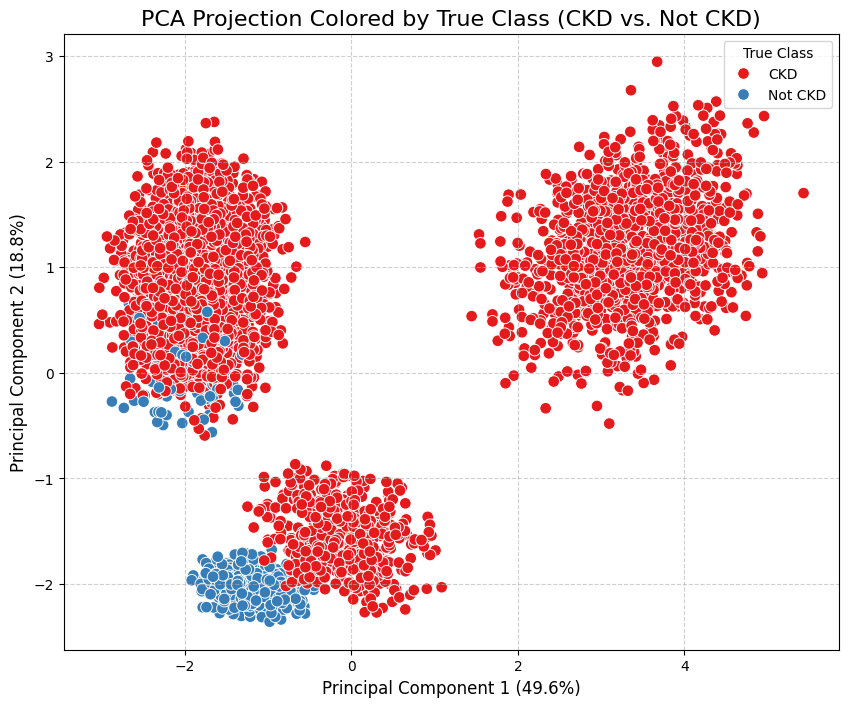

In [109]:
# CDK VS Not CDK

df_pca = pd.DataFrame(data=X_pca, columns=['Principal_Component_1', 'Principal_Component_2'])
df_pca['Class'] = cleaned['CKD_Code'] 
df_pca['Class_Label'] = df_pca['Class'].map({1: 'CKD', 0: 'Not CKD'})


plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='Principal_Component_1', 
    y='Principal_Component_2', 
    hue='Class_Label', 
    data=df_pca, 
    palette='Set1', 
    legend='full',
    s=70 
)

# 
explained_variance_pc1 = pca.explained_variance_ratio_[0]*100
explained_variance_pc2 = pca.explained_variance_ratio_[1]*100

plt.title('PCA Projection Colored by True Class (CKD vs. Not CKD)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({explained_variance_pc1:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance_pc2:.1f}%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='True Class')
plt.show()

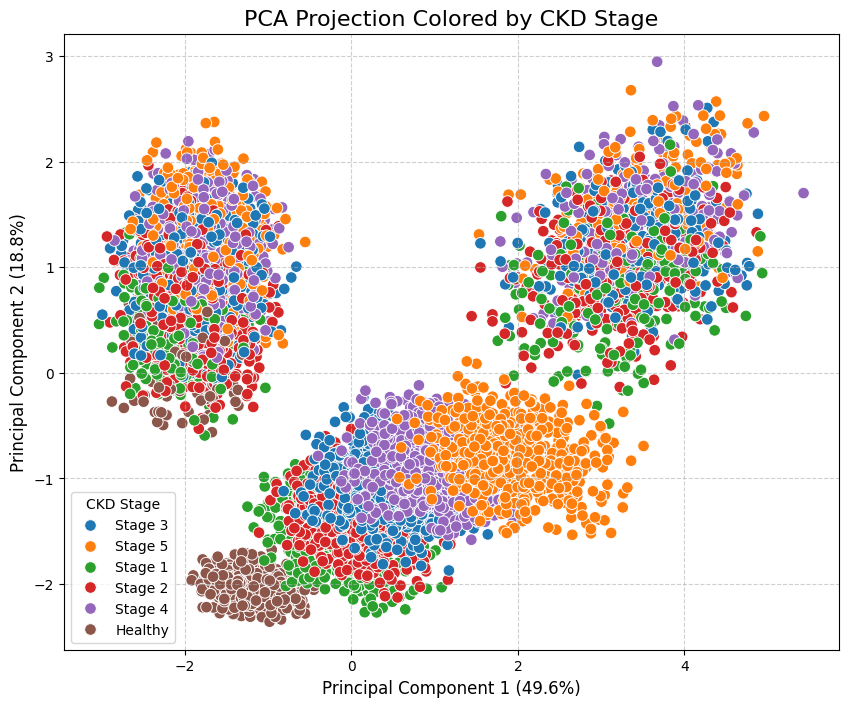

In [ ]:
# whitch_Stage

df_pca = pd.DataFrame(data=X_pca, columns=['Principal_Component_1', 'Principal_Component_2'])

df_pca['Stage'] = cleaned['ckd_stage']  


stage_labels = {0: 'Healthy', 1: 'Stage 1', 2: 'Stage 2', 3: 'Stage 3', 4: 'Stage 4', 5: 'Stage 5'}
df_pca['Stage_Label'] = df_pca['Stage'].map(stage_labels)


plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal_Component_1',
    y='Principal_Component_2',
    hue='Stage_Label',
    data=df_pca,
    palette='tab10',  
    legend='full',
    s=70
)


explained_variance_pc1 = pca.explained_variance_ratio_[0]*100
explained_variance_pc2 = pca.explained_variance_ratio_[1]*100

plt.title('PCA Projection Colored by CKD Stage', fontsize=16)
plt.xlabel(f'Principal Component 1 ({explained_variance_pc1:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance_pc2:.1f}%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='CKD Stage')
plt.show()
